# Synthetic data quality checks (Week 2–3)

Lightweight validation of CSV outputs under `data/synthetic/` before SQL and analytics layers.

**Inputs:** `members`, `advertisers`, `campaigns`, `campaign_experiment_assignments`, `ad_events`, `transactions`.

**Run:** Execute top-to-bottom after generating data with the Week 2–3 scripts (including `generate_ad_events.py` and `generate_transactions.py` when available).

In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd
from IPython.display import display

# Project root: cwd, or parent when the kernel runs from ``notebooks/``
ROOT = Path.cwd()
if not (ROOT / "data" / "synthetic").is_dir() and (ROOT.parent / "data" / "synthetic").is_dir():
    ROOT = ROOT.parent

SYNTHETIC = ROOT / "data" / "synthetic"

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}" if abs(x) < 1e6 else f"{x:,.2f}")

print(f"ROOT={ROOT}")
print(f"SYNTHETIC={SYNTHETIC}")

ROOT=/Users/pratikdahal/Desktop/internship/retail-media-platform
SYNTHETIC=/Users/pratikdahal/Desktop/internship/retail-media-platform/data/synthetic


## Load CSVs

Missing files are skipped (`None`) so you can run partial checks during pipeline bring-up.

In [2]:
def load_csv(name: str) -> pd.DataFrame | None:
    path = SYNTHETIC / name
    if not path.is_file():
        print(f"SKIP (missing): {path}")
        return None
    return pd.read_csv(path)


members = load_csv("members.csv")
advertisers = load_csv("advertisers.csv")
campaigns = load_csv("campaigns.csv")
assignments = load_csv("campaign_experiment_assignments.csv")
ad_events = load_csv("ad_events.csv")
transactions = load_csv("transactions.csv")

## Row counts

In [3]:
rows = {
    "members": len(members) if members is not None else None,
    "advertisers": len(advertisers) if advertisers is not None else None,
    "campaigns": len(campaigns) if campaigns is not None else None,
    "campaign_experiment_assignments": len(assignments) if assignments is not None else None,
    "ad_events": len(ad_events) if ad_events is not None else None,
    "transactions": len(transactions) if transactions is not None else None,
}
display(pd.Series(rows, name="n_rows").to_frame())

,n_rows
members,25000
advertisers,8
campaigns,24
campaign_experiment_assignments,1205
ad_events,170396
transactions,2709


## Schema & required columns

Aligned with `tests/test_data_generation.py`, `tests/test_experiment_assignment.py`, and Week 3 generators.

In [4]:
REQUIRED = {
    "members": {
        "member_id",
        "retailer_id",
        "audience_segment_id",
        "primary_geo_id",
        "signup_date",
        "outcome_currency",
    },
    "advertisers": {"advertiser_id", "advertiser_name", "retailer_id", "vertical_code", "created_at"},
    "campaigns": {
        "campaign_id",
        "campaign_name",
        "advertiser_id",
        "retailer_id",
        "channel",
        "pricing_model",
        "bid_price_usd",
        "budget_usd",
        "daily_budget_usd",
        "target_audience_segment_id",
        "target_geo_id",
        "start_date",
        "end_date",
    },
    "assignments": {
        "campaign_id",
        "member_id",
        "experiment_arm",
        "assignment_unit",
        "assignment_method",
        "holdout_fraction",
    },
    "ad_events": {
        "event_id",
        "member_id",
        "campaign_id",
        "timestamp",
        "event_type",
        "channel",
        "cost",
        "advertiser_id",
        "retailer_id",
    },
    "transactions": {
        "transaction_id",
        "member_id",
        "retailer_id",
        "audience_segment_id",
        "order_timestamp",
        "order_value_usd",
        "outcome_currency",
        "purchase_driver",
        "source_campaign_id",
    },
}

frames = {
    "members": members,
    "advertisers": advertisers,
    "campaigns": campaigns,
    "assignments": assignments,
    "ad_events": ad_events,
    "transactions": transactions,
}

issues: list[str] = []
for label, df in frames.items():
    if df is None:
        continue
    req = REQUIRED[label]
    missing = req - set(df.columns)
    extra_hint = set(df.columns) - req
    if missing:
        issues.append(f"{label}: missing columns {sorted(missing)}")
    print(f"{label}: {len(df.columns)} columns; required OK={not missing}")
    if extra_hint and len(extra_hint) <= 8:
        print(f"  (extra: {sorted(extra_hint)})")

if issues:
    print("Schema issues:")
    for line in issues:
        print(" -", line)
else:
    print("Schema check: OK")

members: 6 columns; required OK=True
advertisers: 5 columns; required OK=True
campaigns: 13 columns; required OK=True
assignments: 6 columns; required OK=True
ad_events: 9 columns; required OK=True
transactions: 9 columns; required OK=True
Schema check: OK


## Nulls (key columns)

Focus on identifiers, timestamps, and fields used for joins.

In [5]:
def null_summary(df: pd.DataFrame | None, cols: list[str], label: str) -> pd.Series | None:
    if df is None:
        return None
    present = [c for c in cols if c in df.columns]
    s = df[present].isna().sum()
    s.name = label
    return s


null_tables = []
if members is not None:
    null_tables.append(null_summary(members, ["member_id", "retailer_id", "audience_segment_id"], "members"))
if advertisers is not None:
    null_tables.append(null_summary(advertisers, ["advertiser_id", "retailer_id"], "advertisers"))
if campaigns is not None:
    null_tables.append(
        null_summary(
            campaigns,
            ["campaign_id", "advertiser_id", "retailer_id", "start_date", "end_date"],
            "campaigns",
        )
    )
if assignments is not None:
    null_tables.append(null_summary(assignments, ["campaign_id", "member_id", "experiment_arm"], "assignments"))
if ad_events is not None:
    null_tables.append(null_summary(ad_events, ["event_id", "member_id", "campaign_id", "timestamp", "event_type"], "ad_events"))
if transactions is not None:
    null_tables.append(
        null_summary(
            transactions,
            ["transaction_id", "member_id", "order_timestamp", "order_value_usd", "purchase_driver", "source_campaign_id"],
            "transactions",
        )
    )

_parts = [t for t in null_tables if t is not None]
if _parts:
    display(pd.concat(_parts, axis=1).fillna(0).astype(int))
else:
    print("SKIP null summary (no frames loaded)")

,members,advertisers,campaigns,assignments,ad_events,transactions
member_id,0,0,0,0,0,0
retailer_id,0,0,0,0,0,0
audience_segment_id,0,0,0,0,0,0
advertiser_id,0,0,0,0,0,0
campaign_id,0,0,0,0,0,0
start_date,0,0,0,0,0,0
end_date,0,0,0,0,0,0
experiment_arm,0,0,0,0,0,0
event_id,0,0,0,0,0,0
timestamp,0,0,0,0,0,0


## Key uniqueness

In [6]:
checks: list[tuple[str, str, list[str]]] = [
    ("members", "member_id unique", ["member_id"]),
    ("advertisers", "advertiser_id unique", ["advertiser_id"]),
    ("campaigns", "campaign_id unique", ["campaign_id"]),
    ("assignments", "campaign_id+member_id unique", ["campaign_id", "member_id"]),
    ("ad_events", "event_id unique", ["event_id"]),
    ("transactions", "transaction_id unique", ["transaction_id"]),
]

for label, desc, keys in checks:
    df = frames[label]
    if df is None:
        print(f"{label}: SKIP")
        continue
    dup = df.duplicated(subset=keys).sum()
    ok = dup == 0
    print(f"{label} ({desc}): {'OK' if ok else 'FAIL'}  duplicates={int(dup)}")

members (member_id unique): OK  duplicates=0
advertisers (advertiser_id unique): OK  duplicates=0
campaigns (campaign_id unique): OK  duplicates=0
assignments (campaign_id+member_id unique): OK  duplicates=0
ad_events (event_id unique): OK  duplicates=0
transactions (transaction_id unique): OK  duplicates=0


## Foreign keys (spot checks)

Assignment rows should reference known members and campaigns.

In [7]:
if assignments is not None and members is not None and campaigns is not None:
    bad_m = set(assignments["member_id"]) - set(members["member_id"])
    bad_c = set(assignments["campaign_id"]) - set(campaigns["campaign_id"])
    print(f"assignments → members: orphan member_ids={len(bad_m)}")
    print(f"assignments → campaigns: orphan campaign_ids={len(bad_c)}")
else:
    print("SKIP FK checks (need assignments, members, campaigns)")

assignments → members: orphan member_ids=0
assignments → campaigns: orphan campaign_ids=0


## Experiment arms: treatment vs control

Expect `assignment_method=randomized_holdout`, `assignment_unit=user`, and control share near `holdout_fraction` when counts are large enough.

In [8]:
if assignments is not None:
    print("experiment_arm value counts:")
    display(assignments["experiment_arm"].value_counts())
    print("metadata:")
    display(
        assignments[["assignment_unit", "assignment_method", "holdout_fraction"]]
        .drop_duplicates()
        .head(5)
    )
    arm_by_c = (
        assignments.assign(is_control=assignments["experiment_arm"].eq("control"))
        .groupby("campaign_id", as_index=False)
        .agg(n=("member_id", "count"), control_rate=("is_control", "mean"))
        .sort_values("campaign_id")
    )
    display(arm_by_c.head(10))
    print(
        f"Overall control rate: {assignments['experiment_arm'].eq('control').mean():.4f} "
        f"(configured holdout_fraction mode={assignments['holdout_fraction'].mode().iloc[0] if len(assignments) else 'n/a'})"
    )
else:
    print("SKIP (no assignments)")

experiment_arm value counts:


experiment_arm
treatment    844
control      361
Name: count, dtype: int64

metadata:


,assignment_unit,assignment_method,holdout_fraction
0,user,randomized_holdout,0.3333
45,user,randomized_holdout,0.2679
101,user,randomized_holdout,0.3261
147,user,randomized_holdout,0.3488
190,user,randomized_holdout,0.3571


,campaign_id,n,control_rate
0,1,45,0.3778
1,2,56,0.2857
2,3,46,0.3043
3,4,43,0.3721
4,5,42,0.4524
5,6,50,0.3200
6,7,56,0.1964
7,8,46,0.4348
8,9,64,0.1406
9,10,49,0.3878


Overall control rate: 0.2996 (configured holdout_fraction mode=0.3260869565217391)


## Ad events: volumes, exposure, CTR

Impressions should dominate; clicks are sampled from impressions. Only **treatment** assignments receive ad exposure in the generator.

In [9]:
if ad_events is not None:
    ev = ad_events["event_type"].value_counts()
    display(ev.to_frame("n_events"))
    imps = ad_events["event_type"].eq("impression").sum()
    clk = ad_events["event_type"].eq("click").sum()
    ctr = clk / imps if imps else float("nan")
    print(f"Global CTR (clicks / impressions): {ctr:.4f}")

    ctr_ch = (
        ad_events.pivot_table(index="channel", columns="event_type", values="event_id", aggfunc="count", fill_value=0)
        .rename_axis(None, axis=1)
    )
    if "click" in ctr_ch.columns and "impression" in ctr_ch.columns:
        ctr_ch["ctr"] = ctr_ch["click"] / ctr_ch["impression"].replace(0, pd.NA)
    display(ctr_ch)

    if assignments is not None:
        treat_keys = assignments.loc[assignments["experiment_arm"].eq("treatment"), ["campaign_id", "member_id"]].drop_duplicates()
        exp_pairs = (
            ad_events.loc[ad_events["event_type"].eq("impression"), ["campaign_id", "member_id"]]
            .drop_duplicates()
            .merge(treat_keys, on=["campaign_id", "member_id"], how="inner")
        )
        exposed_rate = len(exp_pairs) / len(treat_keys) if len(treat_keys) else float("nan")
        print(
            f"Treatment members with ≥1 impression (pair coverage): {len(exp_pairs):,} / {len(treat_keys):,} "
            f"({exposed_rate:.2%})"
        )
else:
    print("SKIP (no ad_events)")

,n_events
event_type,
impression,169404
click,992


Global CTR (clicks / impressions): 0.0059


,click,impression,ctr
channel,,,
onsite_display,306,52302,0.0059
onsite_video,324,75714,0.0043
sponsored_products,362,41388,0.0087


Treatment members with ≥1 impression (pair coverage): 844 / 844 (100.00%)


## Transactions: baseline vs incremental, revenue

`purchase_driver` separates organic propensity from incremental lift. `source_campaign_id` is set for incremental rows only.

In [10]:
if transactions is not None:
    tx = transactions.copy()
    tx["order_timestamp"] = pd.to_datetime(tx["order_timestamp"], errors="coerce")
    print("purchase_driver:")
    display(tx["purchase_driver"].value_counts().to_frame("n_orders"))

    rev = tx.groupby("purchase_driver", as_index=False).agg(
        orders=("transaction_id", "count"),
        revenue_usd=("order_value_usd", "sum"),
        avg_order_usd=("order_value_usd", "mean"),
    )
    display(rev)

    inc = tx.loc[tx["purchase_driver"].eq("incremental"), "source_campaign_id"]
    print(f"Incremental rows with missing source_campaign_id: {inc.isna().sum()}")
else:
    print("SKIP (no transactions)")

purchase_driver:


,n_orders
purchase_driver,
baseline,2535
experiment_conversion,174


,purchase_driver,orders,revenue_usd,avg_order_usd
0,baseline,2535,"107,806.9900",42.5274
1,experiment_conversion,174,"7,031.1400",40.4089


Incremental rows with missing source_campaign_id: 0


## Campaign-level rollups (optional)

Join spend from `ad_events` and incremental revenue from `transactions` for a quick sanity check.

In [11]:
if campaigns is not None and ad_events is not None and transactions is not None:
    spend = ad_events.groupby("campaign_id", as_index=False).agg(ad_spend_usd=("cost", "sum"), n_ad_events=("event_id", "count"))
    inc_rev = (
        transactions.loc[transactions["purchase_driver"].eq("incremental")]
        .groupby("source_campaign_id", as_index=False)
        .agg(incremental_revenue_usd=("order_value_usd", "sum"), incremental_orders=("transaction_id", "count"))
        .rename(columns={"source_campaign_id": "campaign_id"})
    )
    rollup = campaigns[["campaign_id", "campaign_name", "channel", "retailer_id", "budget_usd"]].merge(spend, on="campaign_id", how="left").merge(
        inc_rev, on="campaign_id", how="left"
    )
    rollup["incremental_revenue_usd"] = rollup["incremental_revenue_usd"].fillna(0)
    rollup["incremental_orders"] = rollup["incremental_orders"].fillna(0).astype(int)
    display(rollup.sort_values("campaign_id").head(12))
else:
    print("SKIP campaign rollup (need campaigns, ad_events, transactions)")

,campaign_id,campaign_name,channel,retailer_id,budget_usd,ad_spend_usd,n_ad_events,incremental_revenue_usd,incremental_orders
0,1,campaign_001,onsite_video,1,"20,166.1100",101.1360,7261,0.0000,0
1,2,campaign_002,onsite_display,2,"23,696.3500",137.7600,9901,0.0000,0
2,3,campaign_003,onsite_display,2,"31,187.4600",53.7600,3865,0.0000,0
3,4,campaign_004,onsite_display,2,"26,301.9400",111.1320,7984,0.0000,0
4,5,campaign_005,onsite_video,1,"23,259.2300",42.5040,3051,0.0000,0
5,6,campaign_006,sponsored_products,1,"23,470.2700",73.9500,9879,0.0000,0
6,7,campaign_007,onsite_video,1,"13,898.1300",52.9200,3793,0.0000,0
7,8,campaign_008,sponsored_products,1,"3,655.6700",31.4500,3937,0.0000,0
8,9,campaign_009,sponsored_products,1,"18,876.9000",118.1500,15649,0.0000,0
9,10,campaign_010,onsite_display,2,"10,546.9300",118.4400,8510,0.0000,0


## Quick plots

Two small charts: control rate by campaign (experiment balance) and CTR by channel (ad behavior).

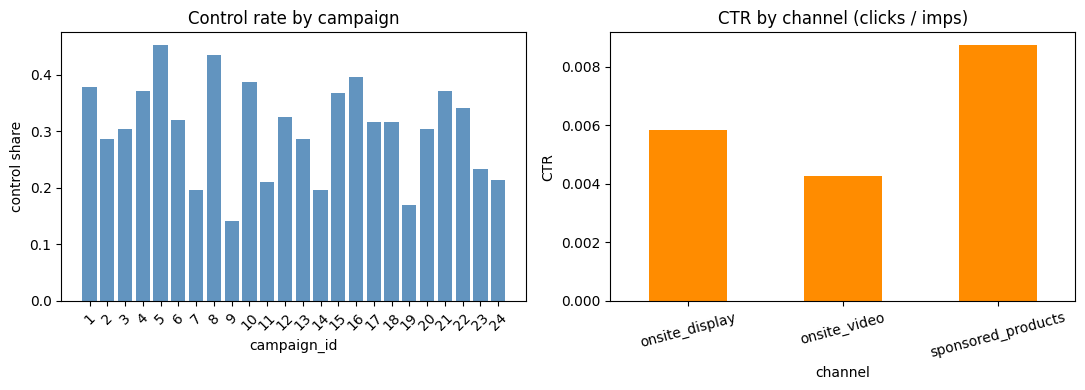

In [12]:
import matplotlib.pyplot as plt

%matplotlib inline

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

if assignments is not None:
    ab = (
        assignments.assign(is_control=assignments["experiment_arm"].eq("control"))
        .groupby("campaign_id", as_index=False)
        .agg(control_rate=("is_control", "mean"))
        .sort_values("campaign_id")
    )
    axes[0].bar(ab["campaign_id"].astype(str), ab["control_rate"], color="steelblue", alpha=0.85)
    axes[0].set_title("Control rate by campaign")
    axes[0].set_xlabel("campaign_id")
    axes[0].set_ylabel("control share")
    axes[0].tick_params(axis="x", rotation=45)
else:
    axes[0].text(0.5, 0.5, "No assignments", ha="center", va="center", transform=axes[0].transAxes)

if ad_events is not None:
    ch = ad_events.pivot_table(index="channel", columns="event_type", values="event_id", aggfunc="count", fill_value=0)
    if "impression" in ch.columns and "click" in ch.columns:
        ctr = (ch["click"] / ch["impression"].replace(0, pd.NA)).astype(float)
        ctr.plot(kind="bar", ax=axes[1], color="darkorange", legend=False)
        axes[1].set_title("CTR by channel (clicks / imps)")
        axes[1].set_xlabel("channel")
        axes[1].set_ylabel("CTR")
        axes[1].tick_params(axis="x", rotation=15)
    else:
        axes[1].text(0.5, 0.5, "Need imp+click", ha="center", va="center", transform=axes[1].transAxes)
else:
    axes[1].text(0.5, 0.5, "No ad_events", ha="center", va="center", transform=axes[1].transAxes)

plt.tight_layout()
plt.show()